Title: PSL_cluster_new.ipynb

Purpose: Make a clustering of large scale weather patterns

Author: Onno Nennecke on 03.06.2025 Modified: 22.05.2026

Input data: 

- PSL Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- kmeans scores: psl_kmeans_score_diff_k.csv
    - This file lies here: /home/onennecke/psl_clustering/psl_kmeans_score_diff_k.csv
- Kmeans score Plot: PSL_cluster_elbow_silhouette
    - This file lies here: /home/onennecke/Code/Figures/
- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc_2.npz


### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
# import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
# import time
import cftime
# import datetime
from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets['ESM_run'] = ts_datasets['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)
# ts_datasets

### Select only relevant timesteps for the clustering!!

In [4]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_dat = LEE_dat[LEE_dat['date_start'].str[5:7] != '04']


In [5]:
ts_datasets_filtered = ts_datasets.copy()
date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
ts_datasets_filtered = ts_datasets.copy()
mask = xr.zeros_like(ts_datasets_filtered.time, dtype=bool)

for esm, dates in date_map.items():
    dates_formatted = [
        cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
        for date in dates
    ]

    mask = mask | (
        (ts_datasets_filtered.ESM_run == esm) &
        (ts_datasets_filtered.time.isin(dates_formatted))
    )

ts_datasets_filtered = ts_datasets_filtered.where(mask, drop=True)

# Clustering

In [6]:
psl = ts_datasets_filtered['psl']

# Stack lat/lon into a single "space" dimension to prepare for PCA and clustering
psl_stacked = psl.stack(sample=("time", "ESM_run"))
# remove samples that are fully NaN
psl_stacked = psl_stacked.dropna(dim="sample", how="all")
psl_2d = psl_stacked.stack(space=("lat", "lon"))
X = psl_2d.values

weights = np.repeat(
    np.sqrt(np.cos(np.deg2rad(psl.lat.values))),
    psl.sizes["lon"]
)
X_weighted = X * weights[np.newaxis, :]

# PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X_weighted)  # shape: (n_times, n_eofs)
# print(pca.n_components_)
# print("Explained variance ratio per component:", pca.explained_variance_ratio_)
# print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum())

In [7]:
# Calculate KMeans with optimal k
k_opt = 4 # Code for finding optimal k at the bottom of this script
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# 3. Run KMeans 
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (k, n_eofs)

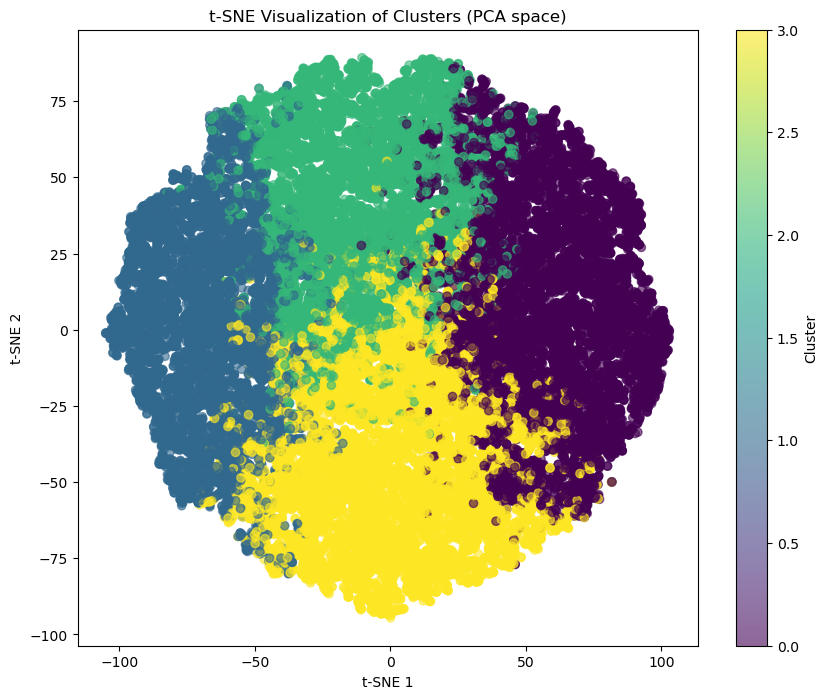

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE to the PCA-transformed data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

# Plot the t-SNE results, colored by cluster labels
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(label='Cluster')
plt.title("t-SNE Visualization of Clusters (PCA space)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

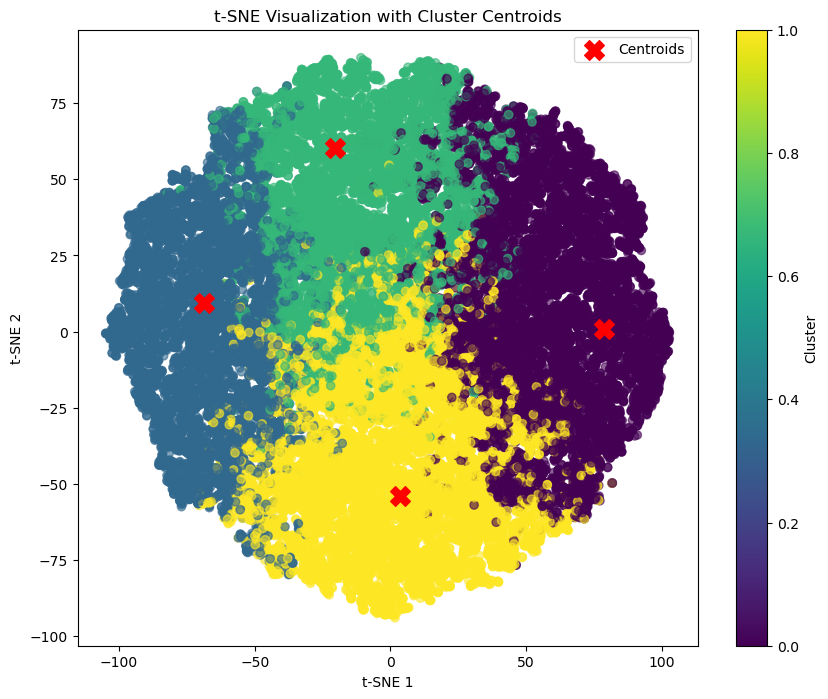

In [10]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Combine data and centroids
X_pca_with_centroids = np.vstack([X_pca, centroids_pca])

# Fit t-SNE on combined data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_all = tsne.fit_transform(X_pca_with_centroids)

# Split back into data and centroids
X_tsne = X_tsne_all[:-k_opt]
centroids_tsne = X_tsne_all[-k_opt:]

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(centroids_tsne[:, 0], centroids_tsne[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.colorbar(label='Cluster')
plt.title("t-SNE Visualization with Cluster Centroids")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.show()

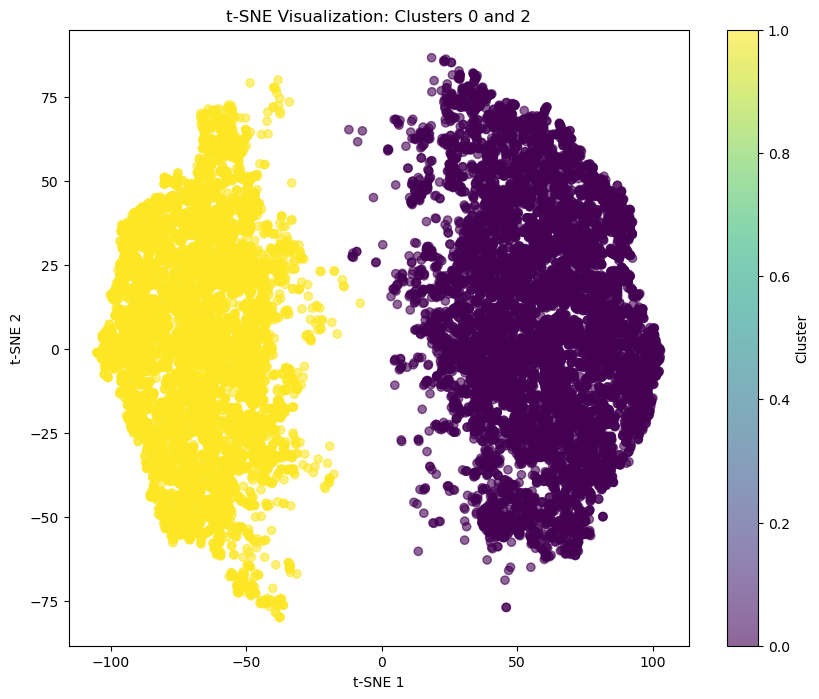

In [14]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE to your PCA-transformed data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

# Filter for clusters 0 and 2
mask = (labels == 0) | (labels == 1)
X_tsne_filtered = X_tsne[mask]
labels_filtered = labels[mask]

# Plot only clusters 0 and 2
plt.figure(figsize=(10, 8))
plt.scatter(
    X_tsne_filtered[:, 0],
    X_tsne_filtered[:, 1],
    c=labels_filtered,
    cmap='viridis',
    alpha=0.6
)
plt.colorbar(label='Cluster')
plt.title("t-SNE Visualization: Clusters 0 and 2")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [9]:
# Save weights and PCA components for later use
joblib.dump(pca, '/home/onennecke/psl_clustering/pca_model.pkl')
joblib.dump(centroids_pca, '/home/onennecke/psl_clustering/kmeans_centers_pca.pkl')
np.save('/home/onennecke/psl_clustering/weights.npy', weights)

In [46]:
pca.n_components_

np.int64(7)

In [8]:
# ----------
# 1. Inverse transform centroids from PCA space to weighted original space
centroids_weighted = pca.inverse_transform(centroids_pca)  # shape: (k, n_lat * n_lon)

# 2. Remove the weighting from the centroids
#    weights is a 1D array of length n_lat * n_lon (or n_lat, repeated for lon)
#    You need to divide each centroid by the weights
centroids_unweighted = centroids_weighted / weights[np.newaxis, :]

# 3. Reshape to lat/lon grid
centroids_reshaped = centroids_unweighted.reshape(k_opt, psl.sizes['lat'], psl.sizes['lon'])

# ----------


# # 4.1 Convert centroids back to original space
# centroids = pca.inverse_transform(centroids_pca)  # shape (k, n_lat * n_lon)

# # 5. Reshape centroids to lat/lon grid
# centroids_reshaped = centroids.reshape(k_opt, psl.sizes['lat'], psl.sizes['lon'])  # shape (k, n_lat, n_lon)

# Count occurrences of each cluster
unique, counts = np.unique(labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print('Original cluster counts: ', cluster_counts)

Original cluster counts:  {np.int32(0): np.int64(9887), np.int32(1): np.int64(7284), np.int32(2): np.int64(7842), np.int32(3): np.int64(10204)}


In [ ]:
# Save centroids and labels to a folder
output_dir = '/home/onennecke/psl_clustering/clustering_results_nbc.npz'
np.savez(output_dir, centroids_reshaped=centroids_reshaped, labels=labels)

In [ ]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_unweighted = data['centroids_reshaped']
centroids_reshaped = centroids_unweighted.reshape(k_opt, psl.sizes['lat'], psl.sizes['lon'])


In [9]:
# Count occurrences of each cluster
unique, counts = np.unique(labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(cluster_counts)

{np.int32(0): np.int64(9887), np.int32(1): np.int64(7284), np.int32(2): np.int64(7842), np.int32(3): np.int64(10204)}


In [10]:
cluster_da = xr.DataArray(
    labels,
    coords={"sample": psl_stacked.sample},
    dims=["sample"]
)
cluster_da = cluster_da.unstack("sample")
cluster_da
# Switch time and ESM run dimension order
cluster_da = cluster_da.transpose("ESM_run", "time")
cluster_da

<xarray.DataArray (ESM_run: 193, time: 1523)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [ 2.,  2.,  2., ..., nan,  3., nan],
       [nan, nan, nan, ...,  3., nan, nan]])
Coordinates:
  * time     (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
  * ESM_run  (ESM_run) object 2kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...

In [12]:
score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.17504067374311175


/tmp/ipykernel_1548589/482387784.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


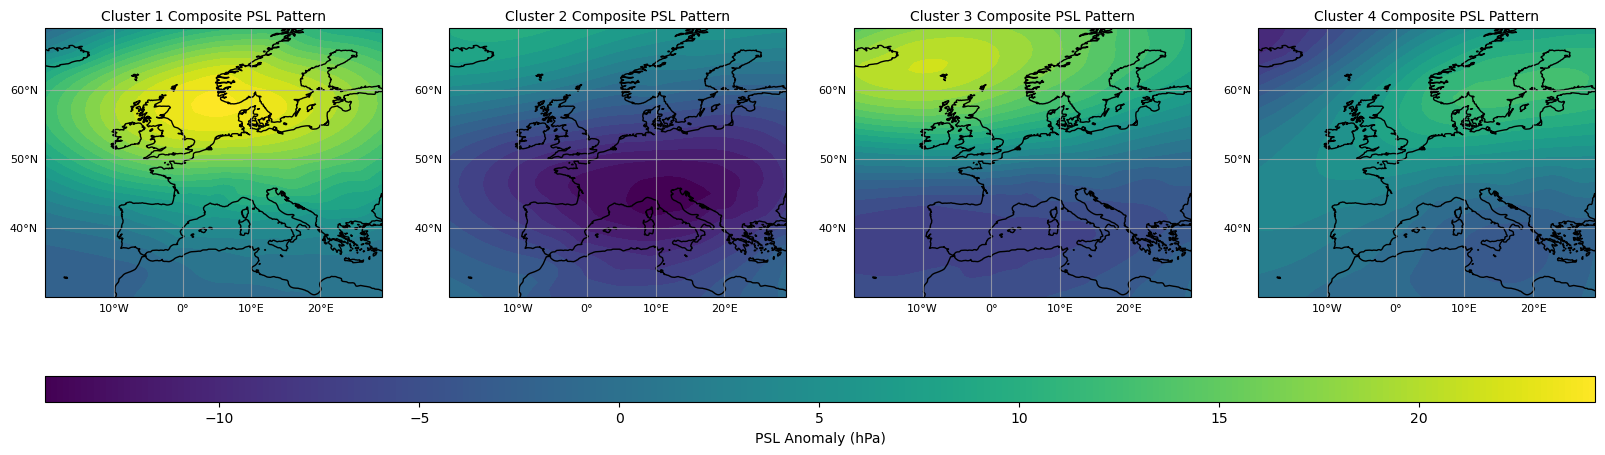

In [14]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = np.nanmax(centroids_reshaped / 100.0)

# 2) Decide on subplot grid
ncols = 4
k_opt = 4
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(centroids_reshaped[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree(), cmap='viridis')
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


### Intermission:

Check if the assignment of the cluster works

/tmp/ipykernel_1548589/2426614419.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


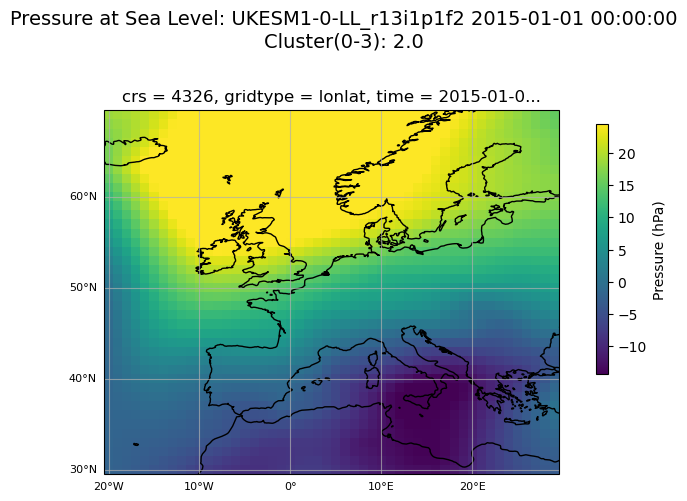

In [27]:
plot_one_timestep(0, -2)

In [ ]:
def plot_one_timestep(t, esm_r):

    # Select a specific ESM run and one time step
    timestep_da = ts_datasets_filtered.isel(time=t, ESM_run=esm_r)

    vmin = np.nanmin(centroids_reshaped / 100.0)
    vmax = np.nanmax(centroids_reshaped / 100.0)

    # Create a figure + Cartopy axis
    fig, ax = plt.subplots(
        nrows=1, ncols=1,
        figsize=(6, 5),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
    new_lon = ((timestep_da.lon + 180) % 360) - 180
    da2 = timestep_da['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
    da2 = da2.load()  # now it’s a NumPy array under the hood

    # Plot with plain‐float vmin/vmax
    p = da2.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap_used,
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)

    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
    plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

    fig.suptitle(f'Pressure at Sea Level: {timestep_da.ESM_run.values} {timestep_da.time.values}\nCluster(0-3): {cluster_da.isel(time = t, ESM_run = esm_r).values}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()

##### Look how the clusters are seasonaly distributed

In [30]:

# Extract coordinates aligned with labels
sample_index = psl_stacked.sample.to_index()

df = pd.DataFrame({
    "time": sample_index.get_level_values("time"),
    "ESM_run": sample_index.get_level_values("ESM_run"),
    "cluster": labels
})

# Optional: add ESM (you already have it in dataset)
# Need to align it properly:
esm_lookup = ts_datasets_filtered["ESM"].to_series()

df["ESM"] = [
    esm_lookup.loc[(t, esm_run)]
    for t, esm_run in zip(df["time"], df["ESM_run"])
]

In [38]:
# Calculate how often each cluster occurs and the occurence probability
cluster_counts = df['cluster'].value_counts().sort_index()
total_counts = len(df)
cluster_probabilities = cluster_counts / total_counts
print("Cluster Occurrences:\n", cluster_counts)
print("\nCluster Occurrence Probabilities:\n", cluster_probabilities)

Cluster Occurrences:
 cluster
0     9887
1     7284
2     7842
3    10204
Name: count, dtype: int64

Cluster Occurrence Probabilities:
 cluster
0    0.280745
1    0.206832
2    0.222677
3    0.289746
Name: count, dtype: float64


--- 

In [39]:
# ────────────── 3) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df["month"]  = df["time"].apply(lambda x: x.month)
df["season"] = df["month"].map(month_to_season)
# df


In [40]:
# ────────────── 4) Count how many samples of each cluster fall in each season ──────────────

# This gives you a table with index = cluster ID, columns = season, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)  
# e.g. monthly_counts.loc[2, "JJA"] is “how many cluster–2 days fall in summer (JJA).”

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
# Now each row sums to 1, so monthly_frac.loc[i, s] is the fraction of cluster i’s samples in season s.


In [41]:
monthly_frac
# Calculate the sum per month
monthly_sum = monthly_counts.sum(axis=0)
monthly_sum
# Oktober passt
# November passt
# Dezember passt
# Januar passt
# Februar passt


month
1     11428
2      5411
3       675
10      257
11     5946
12    11500
dtype: int64

In [42]:
df[0:20]

,time,ESM_run,cluster,ESM,month,season
0,2015-01-01 00:00:00,CESM2_LE2-1071_004,1,CESM2_LE,1,DJF
1,2015-01-01 00:00:00,CESM2_LE2-1171_009,3,CESM2_LE,1,DJF
2,2015-01-01 00:00:00,CESM2_LE2-1231_002,0,CESM2_LE,1,DJF
3,2015-01-01 00:00:00,CESM2_LE2-1231_003,3,CESM2_LE,1,DJF
4,2015-01-01 00:00:00,CESM2_LE2-1231_011,0,CESM2_LE,1,DJF
5,2015-01-01 00:00:00,CESM2_LE2-1231_013,2,CESM2_LE,1,DJF
6,2015-01-01 00:00:00,CESM2_LE2-1231_020,2,CESM2_LE,1,DJF
7,2015-01-01 00:00:00,CESM2_LE2-1251_002,1,CESM2_LE,1,DJF
8,2015-01-01 00:00:00,CESM2_LE2-1251_011,1,CESM2_LE,1,DJF
9,2015-01-01 00:00:00,CESM2_LE2-1251_012,2,CESM2_LE,1,DJF


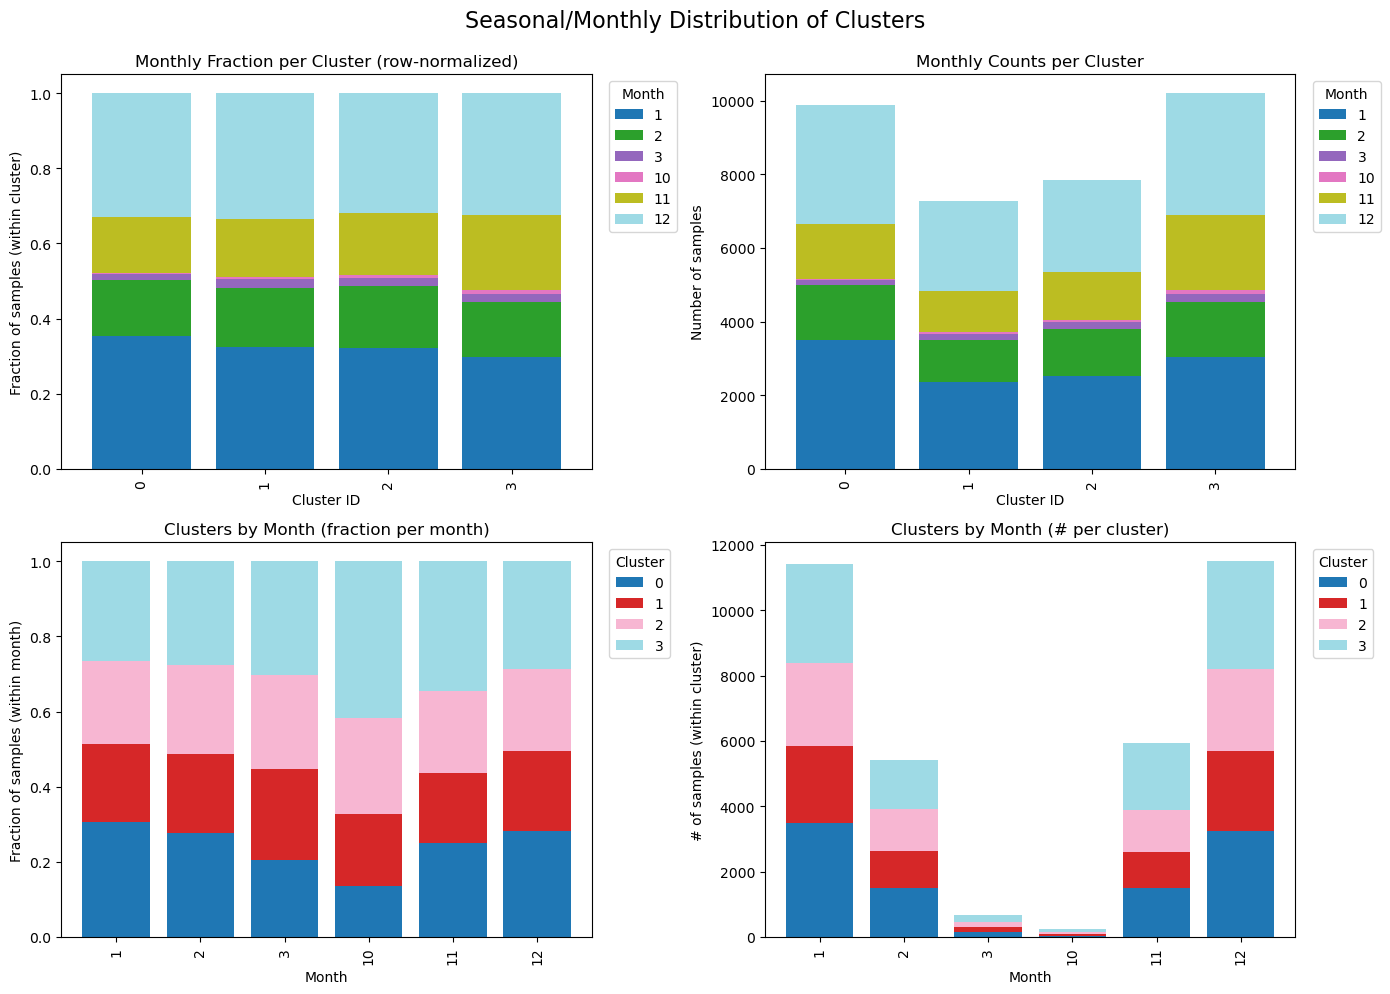

In [43]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# 1) Top‐Left: monthly_frac (clusters on x‐axis, months stacked)
monthly_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20",
    width=0.8
)
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Fraction of samples (within cluster)")
axes[0].set_title("Monthly Fraction per Cluster (row‐normalized)")
axes[0].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Top‐Right: monthly_counts (clusters on x‐axis, months stacked)
monthly_counts.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="tab20",
    width=0.8
)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Monthly Counts per Cluster")
axes[1].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Right: monthly_frac_within_month.T (months on x‐axis, clusters stacked; fraction within month)
monthly_frac_within_month = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

monthly_frac_within_month.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="tab20",
    width=0.8
)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraction of samples (within month)")
axes[2].set_title("Clusters by Month (fraction per month)")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Left: monthly_counts.T (months on x‐axis, clusters stacked; fraction within cluster)
monthly_counts.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[3],
    colormap="tab20",
    width=0.8
)
axes[3].set_xlabel("Month")
axes[3].set_ylabel("# of samples (within cluster)")
axes[3].set_title("Clusters by Month (# per cluster)")
axes[3].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")



# ────────────── D) Adjust layout ──────────────

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Seasonal/Monthly Distribution of Clusters", fontsize=16, y=0.99)
plt.show()

----

### Look at distribution for each ESM

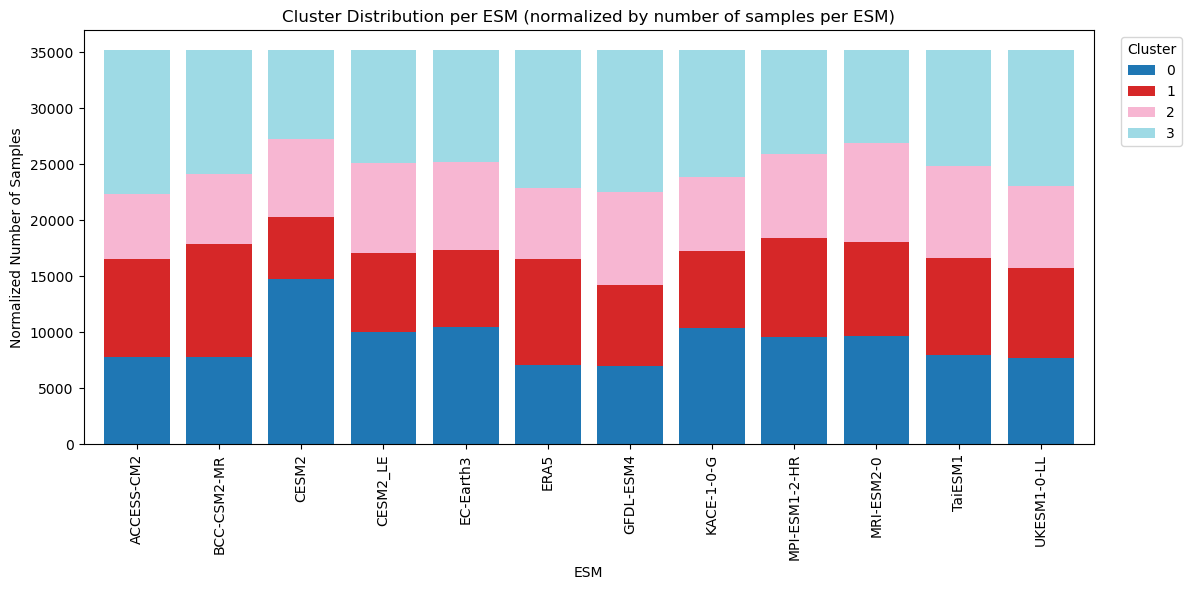

In [44]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Determination of optimal k

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os
import glob
import cftime
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets['ESM_run'] = ts_datasets['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)
# ts_datasets

### Select only relevant timesteps for the clustering!!

In [3]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_dat = LEE_dat[LEE_dat['date_start'].str[5:7] != '04']


In [4]:
ts_datasets_filtered = ts_datasets.copy()
date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
ts_datasets_filtered = ts_datasets.copy()
mask = xr.zeros_like(ts_datasets_filtered.time, dtype=bool)

for esm, dates in date_map.items():
    dates_formatted = [
        cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
        for date in dates
    ]

    mask = mask | (
        (ts_datasets_filtered.ESM_run == esm) &
        (ts_datasets_filtered.time.isin(dates_formatted))
    )

ts_datasets_filtered = ts_datasets_filtered.where(mask, drop=True)

##### Determine optimal k

In [5]:
# !!! Takes a bit if you run it on the full dataset !!!

psl = ts_datasets_filtered['psl']

# Stack lat/lon into a single "space" dimension to prepare for PCA and clustering
psl_stacked = psl.stack(sample=("time", "ESM_run"))
# remove samples that are fully NaN
psl_stacked = psl_stacked.dropna(dim="sample", how="all")
psl_2d = psl_stacked.stack(space=("lat", "lon"))
X = psl_2d.values

weights = np.repeat(
    np.sqrt(np.cos(np.deg2rad(psl.lat.values))),
    psl.sizes["lon"]
)
X_weighted = X * weights[np.newaxis, :]

# PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X_weighted)  # shape: (n_times, n_eofs)
# print(pca.n_components_)
# print("Explained variance ratio per component:", pca.explained_variance_ratio_)
# print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum())

# Calculate KMeans with optimal k
k_opt = 4 # Code for finding optimal k at the bottom of this script
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# 3. Run KMeans 
kmeans.fit(X_pca)  # fit in EOF space

# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    print(f"Testing k = {k_test} ...")
    km = KMeans(n_clusters=k_test, n_init=20, random_state=1)
    labels_k = km.fit_predict(X_pca)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X_pca, labels_k)
    silhouettes.append(silh)


Testing k = 2 ...
Testing k = 3 ...
Testing k = 4 ...
Testing k = 5 ...
Testing k = 6 ...
Testing k = 7 ...
Testing k = 8 ...
Testing k = 9 ...
Testing k = 10 ...


In [ ]:
# Save k_range, inertias and silhouettes in a dataframe
df_results = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette': silhouettes
})
# Save the results to a CSV file
df_results.to_csv('/home/onennecke/psl_clustering/psl_kmeans_high_RL_score_diff_k.csv', index=False)

In [ ]:
df_results

,k,inertia,silhouette
0,2,2.984591e+13,0.259379
1,3,2.618856e+13,0.172837
2,4,2.340016e+13,0.175176
3,5,2.172571e+13,0.165775
4,6,2.040673e+13,0.149954
5,7,1.941392e+13,0.143049
6,8,1.849072e+13,0.141228
7,9,1.781201e+13,0.137370
8,10,1.724110e+13,0.131575


In [ ]:
# Read the results from the CSV file
df_results = pd.read_csv('/home/onennecke/psl_clustering/psl_kmeans_high_RL_score_diff_k.csv')

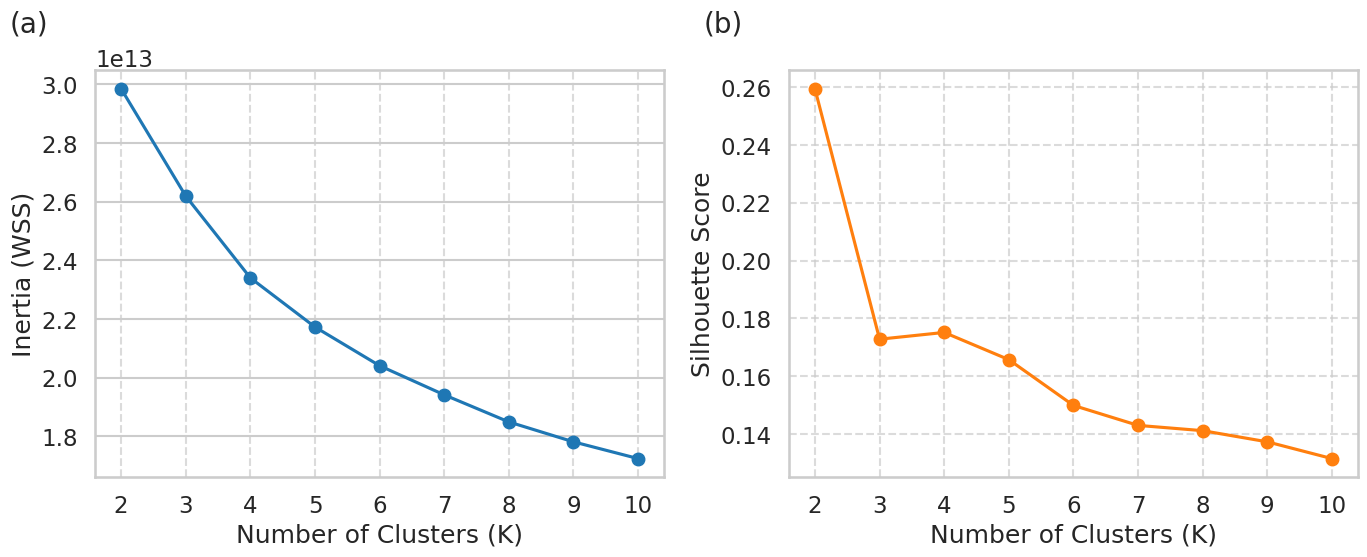

In [7]:
# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


# ensure K is sorted and in a list
ks = sorted(df_results['k'].unique())

sns.set_style("whitegrid")
sns.set_context("talk")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# a) Elbow plot
ax1.plot(df_results['k'], df_results['inertia'], marker='o', linestyle='-', color='C0')
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WSS)")
# ax1.set_ylim(0, df_results['inertia'].max() * 1.1)  # extend y-axis a bit
ax1.set_xticks(ks)                                # label every K
ax1.grid(True, axis='x', linestyle='--', alpha=0.7)  # vertical grid lines
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)  # horizontal grid lines
ax1.text(-0.15, 1.15, "(a)", transform=ax1.transAxes, fontsize = 20, va='top')

# b) Silhouette score
ax2.plot(df_results['k'], df_results['silhouette'], marker='o', linestyle='-', color='C1')
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
# ax2.set_ylim(0, df_results['silhouette'].max() * 1.1)  # extend y-axis a bit
ax2.set_xticks(ks)                                # label every K
ax2.grid(True, axis='x', linestyle='--', alpha=0.7)  # vertical grid lines
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)  # horizontal grid lines
ax2.text(-0.15, 1.15, "(b)", transform=ax2.transAxes, fontsize = 20, va='top')

plt.tight_layout()
# Save the figure
# plt.savefig('/home/onennecke/Code/Figures/PSL_cluster_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()